<a href="https://colab.research.google.com/github/Series-Parallel/Machine_in_Deep_Learning/blob/main/depth_map_from_single_image_using_multi_scale_network_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

training loss equation from paper!

In [2]:
def scale_invariant_loss(pred, gt):
  lambda_val = 0.5
  d = pred - gt

  term1 = torch.mean(d**2)
  term2 = (torch.mean(d)) ** 2

  loss = term1 - lambda_val * term2

  return loss

## network 1 - Global Coarse-Scale net

In [3]:
class CoarseDepthNet(nn.Module):
    def __init__(self):
        super(CoarseDepthNet, self).__init__()

        # coarse 1
        self.conv1 = nn.Conv2d(3, 96, kernel_size=11, stride=4)
        self.pool1 = nn.MaxPool2d(2)

        #coarse 2
        self.conv2 = nn.Conv2d(96, 256, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool2d(2)

        #coarse 3,4,5
        self.conv3 = nn.Conv2d(256, 384, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(384, 384, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(384, 256, kernel_size=3, padding=1)

        #coarse 6,7 fully connected
        self.fc1 = nn.Linear(256 * 13 * 13, 4096) # Corrected from 256 * 6 * 6
        self.fc2 = nn.Linear(4096, 4070 )

    def forward(self, x):

        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        x = x.view(-1, 1, 55, 74)

        return x

In [4]:
model = CoarseDepthNet()

dummy = torch.randn(1,3,224,224)
out = model(dummy)

print(out.shape)

torch.Size([1, 1, 55, 74])


### training the coarse on dummy

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [6]:
images = torch.randn(4, 3, 224, 224)          # dummy RGB images
gt_depth = torch.rand(4, 1, 480, 640)         # dummy ground truth depth

# forward pass
pred_log_depth = model(images)

# downsample ground truth
gt_depth_resized = F.interpolate(
    gt_depth,
    size=(55, 74),
    mode='bilinear',
    align_corners=False
)

# convert to log depth
gt_log_depth = torch.log(gt_depth_resized + 1e-8)

# compute loss
loss = scale_invariant_loss(pred_log_depth, gt_log_depth)

# backprop
optimizer.zero_grad()
loss.backward()
optimizer.step()

print("Loss:", loss.item())

Loss: 0.5360932350158691


upsampling the output of coarse depth ebcause it gave us 55 x 74, but the fine network works at 224 x 224 so we will be doing that before concatening our coarase output with the RGB images!


In [7]:
coarse_depth = (55, 74)

In [8]:
coarse_up = F.interpolate(
    pred_log_depth, # Changed from coarse_depth to pred_log_depth
    size=(224, 224),
    mode="bilinear",
    align_corners=False
)

## network - 2 Local Fine-Scale network

In [9]:
class FineDepthNet(nn.Module):

    def __init__(self):
        super(FineDepthNet, self).__init__()

        self.conv1 = nn.Conv2d(4, 64, kernel_size=9, padding=4)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(64, 1, kernel_size=5, padding=2)

    def forward(self, image, coarse_depth):

        coarse_up = F.interpolate(
            coarse_depth,
            size=(224,224),
            mode='bilinear',
            align_corners=False
        )

        x = torch.cat([image, coarse_up], dim=1)

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.conv3(x)

        return x

In [10]:
fine_model = FineDepthNet()

images = torch.randn(1,3,224,224)
gt_depth = torch.rand(1,1,224,224)

coarse = model(images)

refined = fine_model(images, coarse)

gt_resized = F.interpolate(
    gt_depth,
    size=(224,224),
    mode="bilinear",
    align_corners=False
)

loss = scale_invariant_loss(refined, torch.log(gt_resized + 1e-8))

print("Refined shape:", refined.shape)
print("Loss:", loss.item())

Refined shape: torch.Size([1, 1, 224, 224])
Loss: 1.5238151550292969


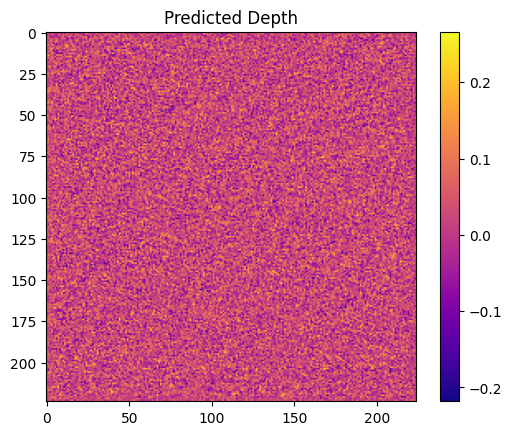

In [11]:
import matplotlib.pyplot as plt

depth = refined.detach().squeeze().cpu()

plt.imshow(depth, cmap="plasma")
plt.colorbar()
plt.title("Predicted Depth")
plt.show()

## trying on the real images!

In [12]:
!wget http://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/nyu_depth_v2_labeled.mat

--2026-03-07 13:15:57--  http://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/nyu_depth_v2_labeled.mat
Resolving horatio.cs.nyu.edu (horatio.cs.nyu.edu)... 216.165.22.17
Connecting to horatio.cs.nyu.edu (horatio.cs.nyu.edu)|216.165.22.17|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/nyu_depth_v2_labeled.mat [following]
--2026-03-07 13:15:57--  https://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/nyu_depth_v2_labeled.mat
Connecting to horatio.cs.nyu.edu (horatio.cs.nyu.edu)|216.165.22.17|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2972037809 (2.8G)
Saving to: ‘nyu_depth_v2_labeled.mat’

nyu_depth_v2_labele 100%[===================>]   2.77G  52.5MB/s    in 59s     

2026-03-07 13:16:57 (48.0 MB/s) - ‘nyu_depth_v2_labeled.mat’ saved [2972037809/2972037809]



In [23]:
import h5py
from torch.utils.data import Dataset, DataLoader
import numpy as np

In [47]:
import h5py

data = h5py.File("nyu_depth_v2_labeled.mat", "r")

print("Images shape:", data["images"].shape)
print("Depths shape:", data["depths"].shape)

Images shape: (1449, 3, 640, 480)
Depths shape: (1449, 640, 480)


In [48]:
class NYUDataset(Dataset):

    def __init__(self, path):
        self.data = h5py.File(path, "r")
        self.images = self.data["images"]
        self.depths = self.data["depths"]

        print("Dataset images shape:", self.images.shape)
        print("Dataset depths shape:", self.depths.shape)

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, idx):

        img = np.array(self.images[idx])      # (3,640,480)
        depth = np.array(self.depths[idx])    # (640,480)

        img = torch.tensor(img).float() / 255
        depth = torch.tensor(depth).float().unsqueeze(0)

        img = F.interpolate(img.unsqueeze(0),(224,224)).squeeze(0)
        depth = F.interpolate(depth.unsqueeze(0),(224,224)).squeeze(0)

        return img, depth

In [49]:
dataset = NYUDataset("nyu_depth_v2_labeled.mat")

loader = DataLoader(dataset, batch_size=4, shuffle=True)

images, gt_depth = next(iter(loader))

print("Batch images:", images.shape)
print("Batch depth:", gt_depth.shape)

Dataset images shape: (1449, 3, 640, 480)
Dataset depths shape: (1449, 640, 480)
Batch images: torch.Size([4, 3, 224, 224])
Batch depth: torch.Size([4, 1, 224, 224])


In [50]:
coarse = model(images)
refined = fine_model(images, coarse)

print("Refined output:", refined.shape)

Refined output: torch.Size([4, 1, 224, 224])


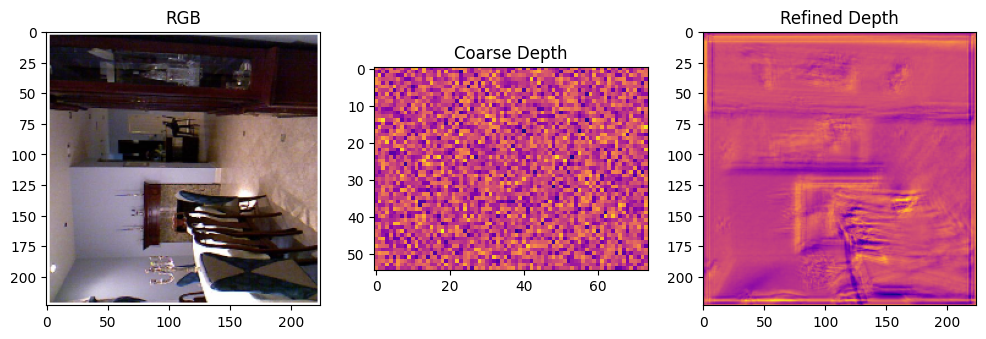

In [51]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(images[0].permute(1,2,0))
plt.title("RGB")

plt.subplot(1,3,2)
plt.imshow(coarse[0].detach().cpu().squeeze(), cmap="plasma")
plt.title("Coarse Depth")

plt.subplot(1,3,3)
plt.imshow(refined[0].detach().cpu().squeeze(), cmap="plasma")
plt.title("Refined Depth")

plt.show()

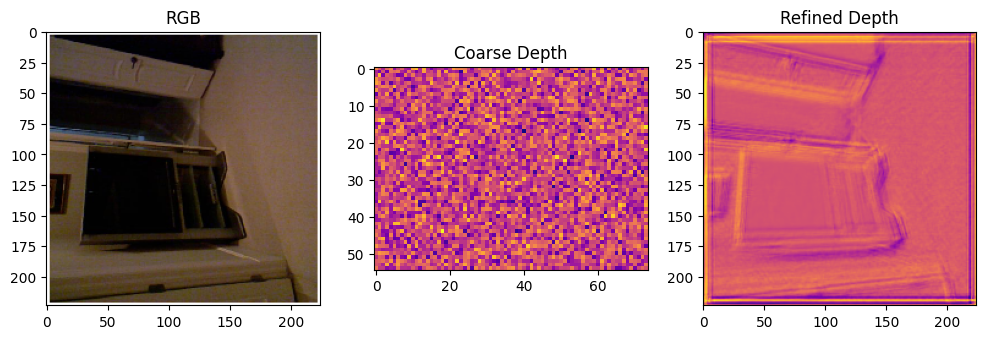

In [58]:
idx = 2

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(images[idx].permute(1,2,0))
plt.title("RGB")

plt.subplot(1,3,2)
plt.imshow(coarse[idx].detach().cpu().squeeze(), cmap="plasma")
plt.title("Coarse Depth")

plt.subplot(1,3,3)
plt.imshow(refined[idx].detach().cpu().squeeze(), cmap="plasma")
plt.title("Refined Depth")

plt.show()

## interesting, now will train it for few epochs :)

In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
fine_model = fine_model.to(device)

In [60]:
print(device)

cuda


In [61]:
optimizer = torch.optim.Adam(
    list(model.parameters()) + list(fine_model.parameters()),
    lr=1e-4
)

In [62]:
epochs = 5

for epoch in range(epochs):

    total_loss = 0

    for images, gt_depth in loader:

        images = images.to(device)
        gt_depth = gt_depth.to(device)

        # forward pass
        coarse = model(images)
        refined = fine_model(images, coarse)

        gt_resized = F.interpolate(
            gt_depth,
            size=(224,224),
            mode="bilinear",
            align_corners=False
        )

        loss = scale_invariant_loss(
            refined,
            torch.log(gt_resized + 1e-8)
        )

        # backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(loader):.4f}")

Epoch 1 | Loss: 0.1894
Epoch 2 | Loss: 0.1651
Epoch 3 | Loss: 0.1554
Epoch 4 | Loss: 0.1564
Epoch 5 | Loss: 0.1500


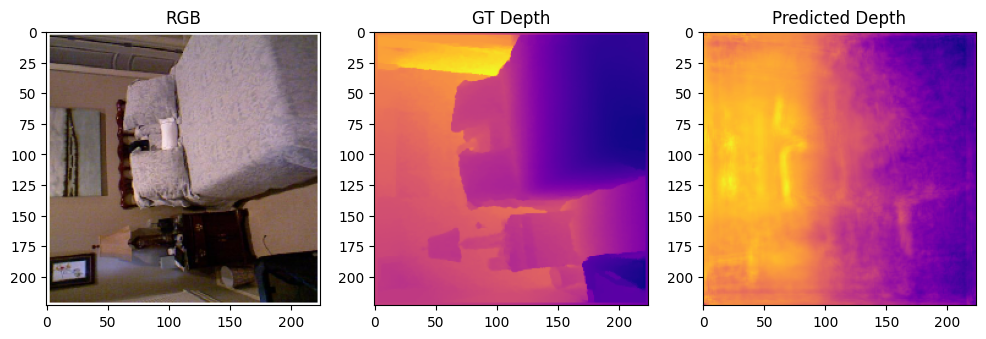

In [63]:
images, gt_depth = next(iter(loader))

images = images.to(device)

with torch.no_grad():
    coarse = model(images)
    refined = fine_model(images, coarse)

idx = 0

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(images[idx].cpu().permute(1,2,0))
plt.title("RGB")

plt.subplot(1,3,2)
plt.imshow(gt_depth[idx].squeeze(), cmap="plasma")
plt.title("GT Depth")

plt.subplot(1,3,3)
plt.imshow(refined[idx].cpu().squeeze(), cmap="plasma")
plt.title("Predicted Depth")

plt.show()